In [1]:
import h5py
import os
import matplotlib.pyplot as plt
import mne 
import sklearn


# Data Analysis

In [2]:
print("Working directory:", os.getcwd())

Working directory: C:\Users\irene\Documents\irene\Università\UU\DL\Final Project data\Final Project data\DL_assignment2


In [3]:
#code snippet to read one file
def get_dataset_name(filename_with_dir):
    filename_without_dir = filename_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = '_'.join(temp)  
    return dataset_name

filename_path = "../Cross/train/rest_164636_1.h5"


with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)


<class 'numpy.ndarray'>
(248, 35624)


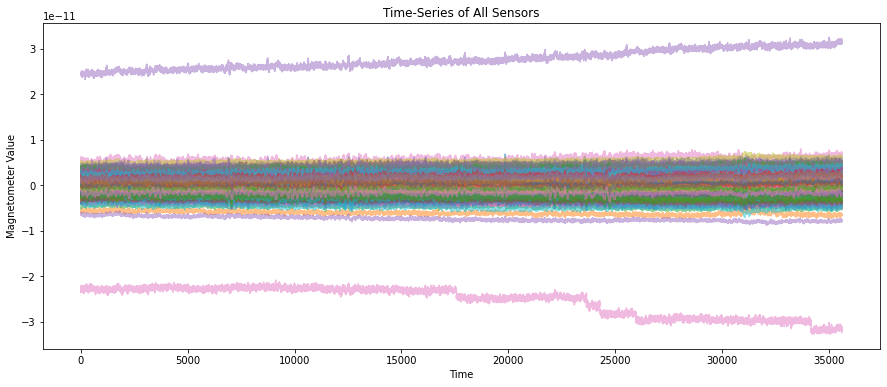

In [4]:
#plot of data points for file /Intra/train/rest_105923_1.h5
plt.figure(figsize=(15, 6))

for i in range(matrix.shape[0]):  # 248 sensors (rows)
    plt.plot(matrix[i], alpha=0.5)  # `alpha` adds transparency to avoid overlap

plt.xlabel('Time')
plt.ylabel('Magnetometer Value')
plt.title('Time-Series of All Sensors')
plt.show()


In [5]:
data_dir = '../Cross/train'

# File listing
files = [f for f in os.listdir(data_dir) if f.endswith('.h5')]

# Preallocate lists
raws = []     # MNE Raw objects
labels = []   # Task labels

# Constants
sfreq = 2034  # Hz, number of samples per second in the signal >> for downsampling later
n_channels = 248 # channel = sensor
ch_names = [f'MEG {i:03d}' for i in range(n_channels)]
ch_types = ['mag'] * n_channels
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types) #metadata; creates MNE info object to store everything about data but actual signal values

# extract full task label (e.g., task_motor, rest)
def get_task_label(filename):
    parts = filename.split('_')
    if parts[0] == 'rest':
        return 'rest'
    elif parts[0] == 'task':
        label_parts = []
        for part in parts[1:]:
            if part.isdigit():
                break
            label_parts.append(part)
        return '_'.join(label_parts)
    else:
        return 'unknown'


# Loop through files
for fname in sorted(files):
    fpath = os.path.join(data_dir, fname)
    task_label = get_task_label(fname)

    with h5py.File(fpath, 'r') as f:
        dataset_name = get_dataset_name(fname)
        data = f[dataset_name][()]  # shape: (248, 35624)

    # Create MNE Raw object, actual MEG data
    raw = mne.io.RawArray(data, info)

    # Store
    raws.append(raw)
    labels.append(task_label)


Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.
Creating RawArray with float64 data, n_channels=248, n_times=35624
    Range : 0 ... 35623

    Range : 0 ... 35623 =      0.000 ...    17.514 secs
Ready.


In [6]:
print(f"Number of recordings: {len(raws)}")
print(f"Unique tasks: {set(labels)}")
print(f"Info: {raw.info}")
data, times = raw[:, :]  # shape: (n_channels, n_times)
print("Min value:", data.min())
print("Max value:", data.max())


Number of recordings: 64
Unique tasks: {'motor', 'rest', 'working_memory', 'story_math'}
Info: <Info | 7 non-empty values
 bads: []
 ch_names: MEG 000, MEG 001, MEG 002, MEG 003, MEG 004, MEG 005, MEG 006, ...
 chs: 248 Magnetometers
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 1017.0 Hz
 meas_date: unspecified
 nchan: 248
 projs: []
 sfreq: 2034.0 Hz
>
Min value: -3.0254182492583936e-10
Max value: 1.5409371695307428e-11


Effective window size : 1.007 (s)
Plotting power spectral density (dB=True).


C:\Users\irene\AppData\Local\Temp/ipykernel_5696/162555123.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=125).plot(picks="data", amplitude=False)
C:\Users\irene\anaconda3\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


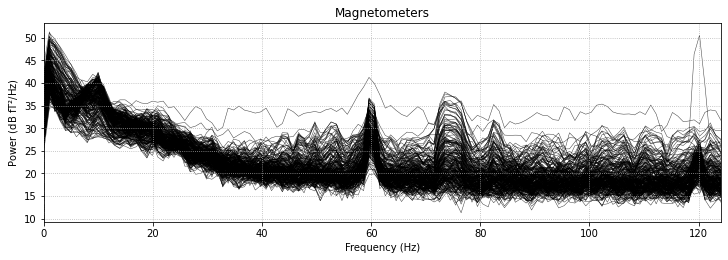

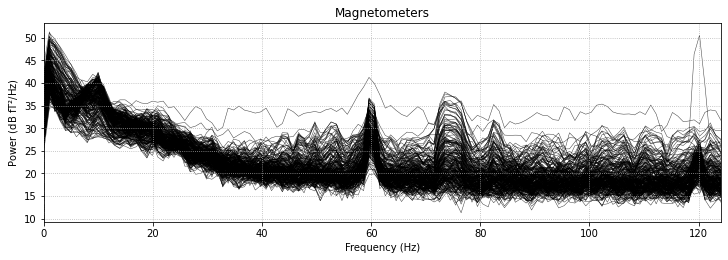

In [7]:
raw.compute_psd(fmax=125).plot(picks="data", amplitude=False)


Plotting task: rest
Using matplotlib as 2D backend.


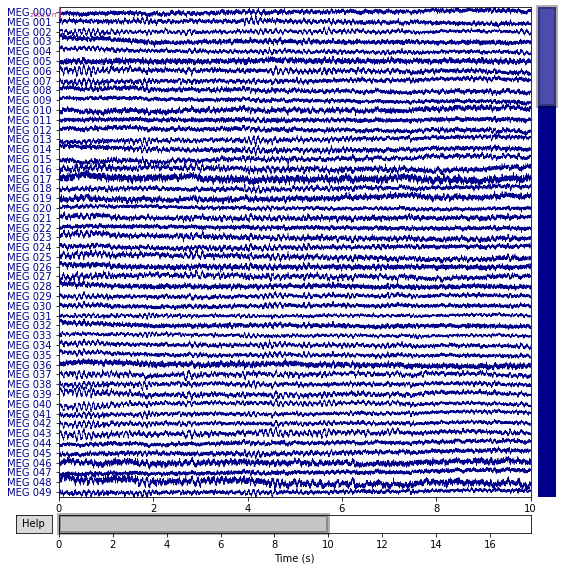

Plotting task: motor


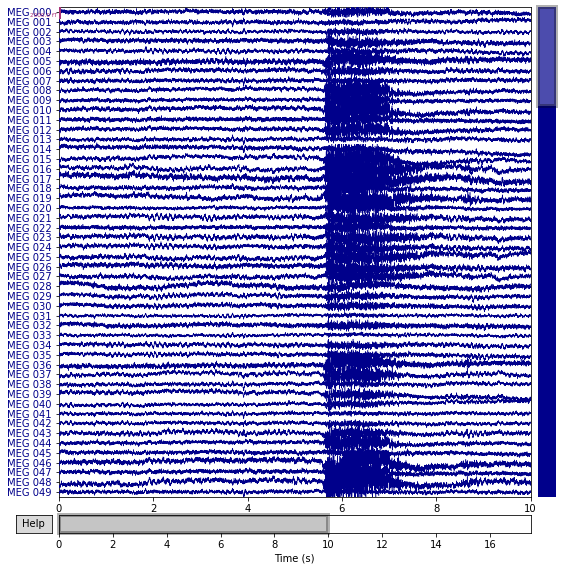

Plotting task: story_math


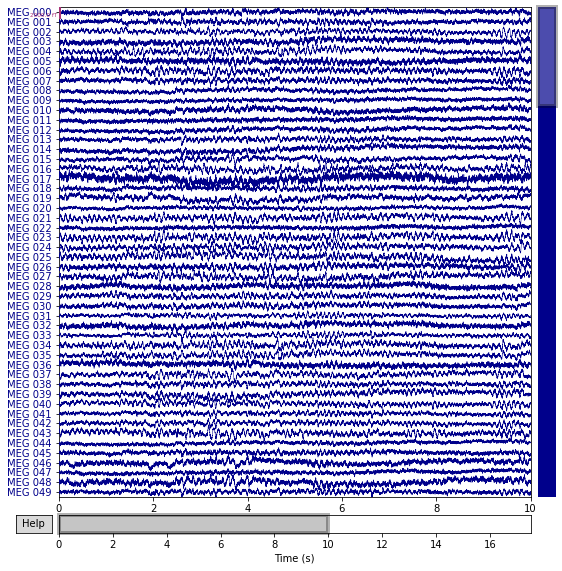

Plotting task: working_memory


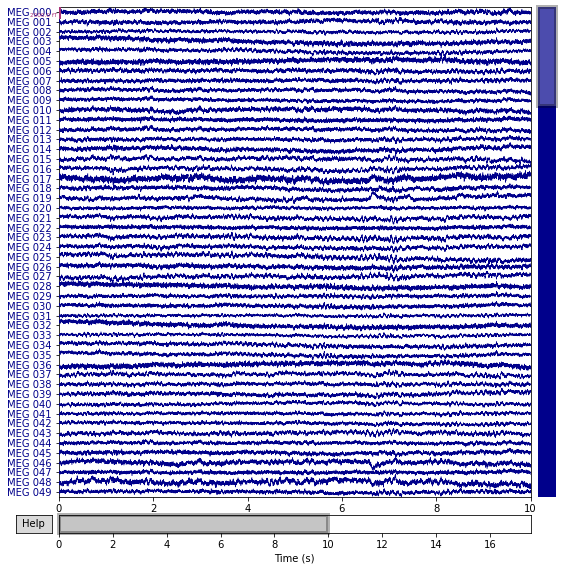

In [8]:
from collections import defaultdict

# Group raw objects by task
task_to_raws = defaultdict(list) #Auto-creates empty list as default value
for raw, label in zip(raws, labels): #Safe even if task wasn't defined yet
    task_to_raws[label].append(raw)

# Plot each task group 
for task, raw_list in task_to_raws.items():
    print(f"Plotting task: {task}")
    # First trail each task
    raw_list[0].plot(n_channels=50, title=f'Task: {task}')


# Data Preprocessing

## Data Downsampling

From 2k Hz to 250Hz. (Look Google Doc why)

In [9]:
resampled_raws = []
for raw in raws:
    raw_resampled = raw.copy().resample(250, verbose=False)
    resampled_raws.append(raw_resampled)

In [10]:
print(raw_resampled.info)

<Info | 7 non-empty values
 bads: []
 ch_names: MEG 000, MEG 001, MEG 002, MEG 003, MEG 004, MEG 005, MEG 006, ...
 chs: 248 Magnetometers
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: unspecified
 nchan: 248
 projs: []
 sfreq: 250.0 Hz
>


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\irene\AppData\Local\Temp/ipykernel_5696/1373144648.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_resampled.compute_psd(fmax=125).plot(picks="data", amplitude=False)
C:\Users\irene\anaconda3\lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


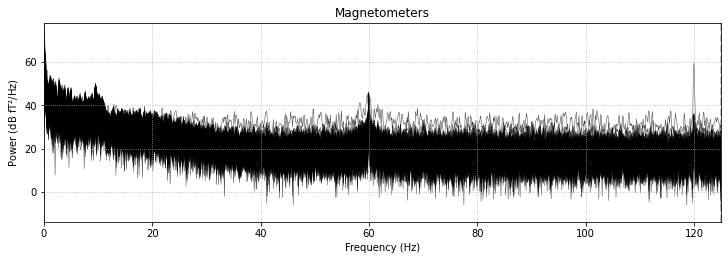

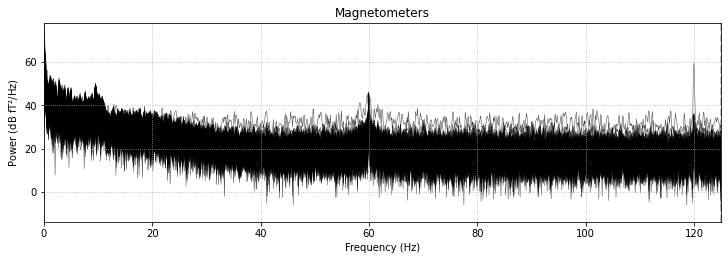

In [11]:
raw_resampled.compute_psd(fmax=125).plot(picks="data", amplitude=False)


Plotting task: rest


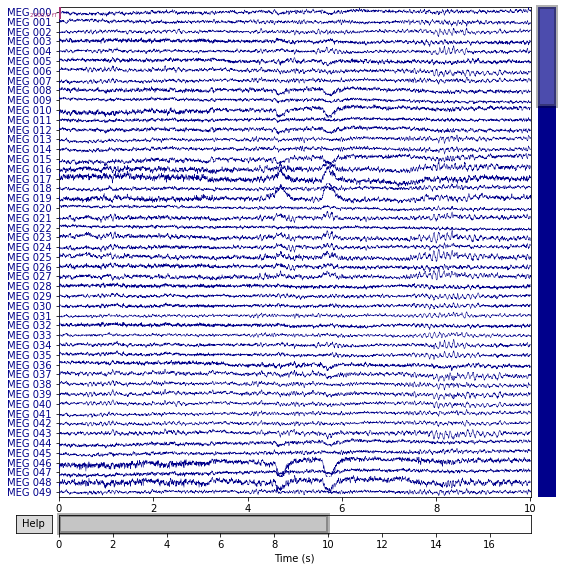

Plotting task: motor


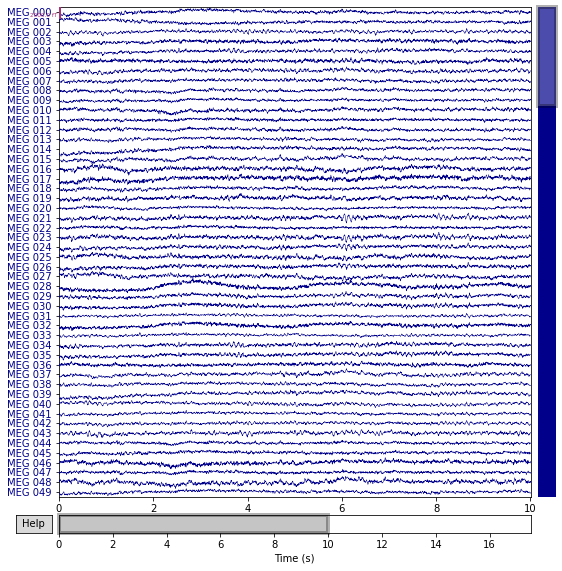

Plotting task: story_math


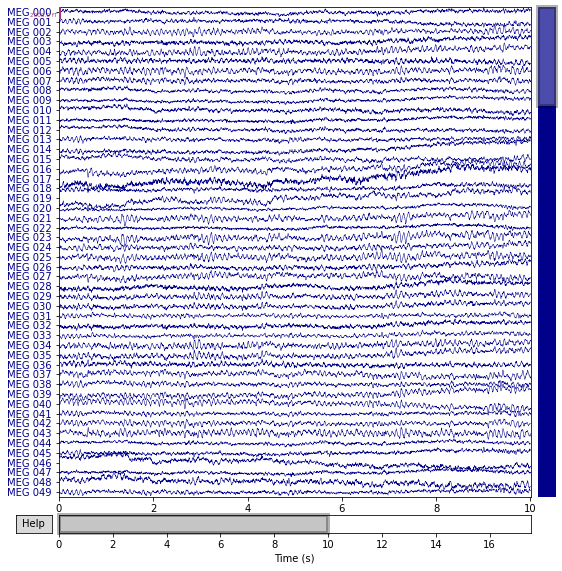

Plotting task: working_memory


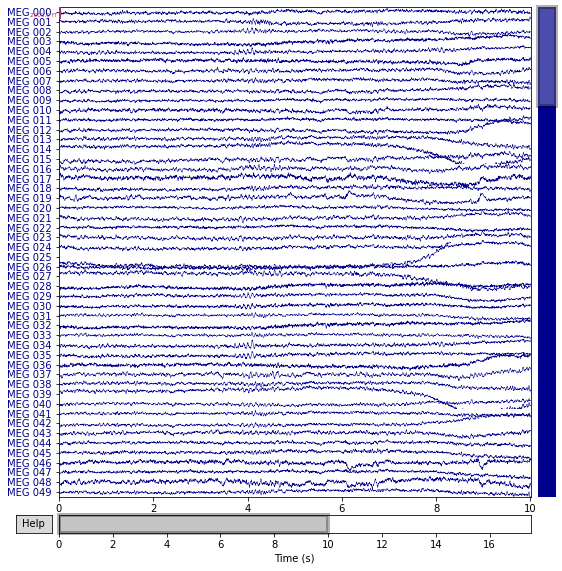

In [12]:
from collections import defaultdict

# Group resampled raw objects by task
task_to_raws = defaultdict(list)
for resampled, label in zip(resampled_raws, labels):  # <-- use resampled_raws here
    task_to_raws[label].append(resampled)

# Plot each task group
for task, raw_list in task_to_raws.items():
    print(f"Plotting task: {task}")
    # Plot the third trial (index 2) of each task if it exists
    if len(raw_list) > 2:
        raw_list[2].plot(n_channels=50, title=f'Task: {task}')


## Normalization 

In [13]:
import numpy as np
#every .h5 file corresponds to one trial, so one epoch of events 
# Extract data arrays and convert to femtoTesla (1 femtoTesla = 10e-15 Tesla)
data_arrays = [raw.get_data() * 1e15 for raw in resampled_raws]
#create 3D array of resampled raws
X = np.stack(data_arrays)  # shape: (n_trials, n_channels, n_times)
# to apply Z-score scaling across trials for each (channel, time) later
mean = X.mean(axis=0)  # shape: (n_channels, n_times)
std = X.std(axis=0)

In [14]:
# Group normalized resampled raw objects by task
task_to_norms = defaultdict(list)
for norm, label in zip(X, labels):
    task_to_norms[label].append(norm)


In [15]:
print(task_to_norms['rest'][0].shape)  # --> (248, 4379)
print(X.shape) # --> (64, 248, 4379)

(248, 4379)
(64, 248, 4379)


In [16]:
import tensorflow as tf
print(tf.__version__)

2.19.0


## Classification 

In [17]:
from tensorflow import keras
print(keras.__version__)

3.10.0


In [18]:
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.models import Model
#from tensorflow.keras.layers import Conv1D, Dense, LSTM, MaxPooling1D

def cnn_att_lstm(input_shape, num_classes=4):
    model = tf.keras.models.Sequential([
                        tf.keras.layers.Conv1D(64, kernel_size=10, activation='relu', input_shape=input_shape),
                        tf.keras.layers.MaxPooling1D(pool_size=3),
                        tf.keras.layers.LSTM(64, return_sequences=False),
                        tf.keras.layers.Dense(num_classes, activation='softmax')
                        ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [19]:
from sklearn.model_selection import StratifiedKFold
#from tensorflow.keras.callbacks import EarlyStopping

def train_kfold(data, labels, build_model_fn, n_splits=8, epochs=50, batch_size=16):
    kf  = StratifiedKFold(n_splits=n_splits)
    y_true, y_pred = [], []

    val_accuracies = []
    val_losses = []

    #callbacks = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

    for i, (train_i, val_i) in enumerate(kf.split(data, labels)):
        print(f"Fold {i+1}/{n_splits}")
        # Split
        X_train, X_val = data[train_i], data[val_i]
        y_train, y_val = labels[train_i], labels[val_i]

        train_mean = X_train.mean(axis=0)   # shape: (n_channels, n_times)
        train_std = X_train.std(axis=0)
        X_train_norm = (X_train - train_mean) / train_std

        val_mean = X_val.mean(axis=0)   # shape: (n_channels, n_times)
        val_std = X_val.std(axis=0)
        X_val_norm = (X_val - val_mean) / val_std

        


        # Train
        model = build_model_fn(X_train_norm.shape[1:], num_classes=4)
        history = model.fit(
            X_train_norm, y_train,
            validation_data=(X_val_norm, y_val),
            epochs=epochs,
            batch_size=batch_size,
            #callbacks=callbacks,
            verbose=1
        )

        val_accuracies.append(max(history.history['val_accuracy']))
        val_losses.append(min(history.history['val_loss']))

        # Evaluate
        y_true.extend(y_val)
        y_pred.extend(model.predict(X_val_norm).argmax(axis=1))

    mean_acc = np.mean(val_accuracies)
    std_acc = np.std(val_accuracies)
    mean_loss = np.mean(val_losses)

    print(f"Mean Validation Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"Mean Validation Loss: {mean_loss:.4f}")

    return y_true, y_pred

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels) 
y_true, y_pred = train_kfold(X, y, cnn_att_lstm, epochs=20)

Fold 1/8


C:\Users\irene\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 525ms/step - accuracy: 0.4500 - loss: 1.1586 - val_accuracy: 0.7500 - val_loss: 0.6588
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.8533 - loss: 0.5179 - val_accuracy: 1.0000 - val_loss: 0.5269
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - accuracy: 0.9640 - loss: 0.3022 - val_accuracy: 1.0000 - val_loss: 0.3714
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - accuracy: 0.9711 - loss: 0.2454 - val_accuracy: 1.0000 - val_loss: 0.3529
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 332ms/step - accuracy: 0.9649 - loss: 0.1709 - val_accuracy: 1.0000 - val_loss: 0.3687
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.9857 - loss: 0.1198 - val_accuracy: 1.0000 - val_loss: 0.3417
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step - accuracy: 0.9774 - loss: 0.1144 - val_accuracy: 1.0000 - val_loss: 0.2253
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step - accuracy: 0.9399 - loss: 0.1444 - val_accuracy: 1.0000 - val_loss:

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.9887 - loss: 0.1745 - val_accuracy: 0.8750 - val_loss: 0.5110
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 0.9824 - loss: 0.1641 - val_accuracy: 0.8750 - val_loss: 0.4945
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.9824 - loss: 0.1564 - val_accuracy: 0.8750 - val_loss: 0.4623
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 1.0000 - loss: 0.1367 - val_accuracy: 0.8750 - val_loss: 0.4776
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 1.0000 - loss: 0.1265 - val_accuracy: 0.8750 - val_loss: 0.4831
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 1.0000 - loss: 0.1366 - val_accuracy: 0.8750 - val_loss: 0.4842
Epoch 17/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 1.0000 - loss: 0.1195 - val_accuracy: 0.8750 - val_loss: 0.5303
Epoch 18/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 1.0000 - loss: 0.1056 - val_accuracy: 0.8750 - val_loss: 0.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
Fold 6/8
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step - accuracy: 0.4363 - loss: 1.1922 - val_accuracy: 0.8750 - val_loss: 0.4901
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 552ms/step - accuracy: 0.9235 - loss: 0.4615 - val_accuracy: 1.0000 - val_loss: 0.3889
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 576ms/step - accuracy: 0.9711 - loss: 0.3271 - val_accuracy: 1.0000 - val_loss: 0.3407
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.9699 - loss: 0.2425 - val_accuracy: 1.0000 - val_loss: 0.3190
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 0.9929 - loss: 0.1897 - val_accuracy: 1.0000 - val_loss: 0.3410
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step - accuracy: 1.0000 - loss: 0.1534 - val_accuracy: 1.0000 - val_loss: 0.3026
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 1.0000 - loss: 0.1192 - val_accuracy: 1.0000 - val_loss: 0.3075
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 1.0000 -

Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 488ms/step - accuracy: 0.9929 - loss: 0.2054 - val_accuracy: 1.0000 - val_loss: 0.2804
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.9887 - loss: 0.1942 - val_accuracy: 1.0000 - val_loss: 0.2577
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 454ms/step - accuracy: 0.9929 - loss: 0.1656 - val_accuracy: 1.0000 - val_loss: 0.2415
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.9824 - loss: 0.1613 - val_accuracy: 1.0000 - val_loss: 0.2310
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.9699 - loss: 0.1524 - val_accuracy: 1.0000 - val_loss: 0.2251
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.9887 - loss: 0.1203 - val_accuracy: 1.0000 - val_loss: 0.2151
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.9887 - loss: 0.1017 - val_accuracy: 1.0000 - val_loss: 0.1899
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.9929 - loss: 0.0971 - val_accuracy: 1.0000 - val_l